# 🛍️ Customer Segmentation Using Unsupervised Learning
### Task 2 | Areeba Hassan 

---

## Project Overview

**Goal:** Segment mall customers into distinct groups using K-Means Clustering, visualize the segments, and propose targeted marketing strategies.

**Dataset:** Mall Customers Dataset (Kaggle) — 200 customers, 5 features

**Pipeline:**
| Step | Task | Status |
|------|------|--------|
| 1 | Load Dataset + EDA | ✅ |
| 2 | K-Means Clustering | ✅ |
| 3 | PCA / t-SNE Visualization | ✅ |
| 4 | Marketing Strategy per Segment | ✅ |
| 5 | GitHub Push with README | ✅ |

---
## ⚙️ Setup — Install & Import Libraries

In [2]:
# Install required libraries (run once)
# kagglehub is Kaggle's modern Python SDK — no API token file needed
!pip install kagglehub -q

In [4]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All libraries imported successfully ✅')

All libraries imported successfully ✅


---
## Step 1 — Load Dataset + Exploratory Data Analysis (EDA)

### 1.1 — Load Data Directly from Kaggle

We use `kagglehub` to download the dataset directly. On first run it will prompt you to log in via browser (one-time setup). After that, the dataset is cached locally.

In [6]:
import os

# Download dataset from Kaggle — authenticates via browser on first run
# Dataset: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
path = kagglehub.dataset_download('vjchoudhary7/customer-segmentation-tutorial-in-python')

print(f'Dataset downloaded to: {path}')
print('Files available:', os.listdir(path))

100%|██████████| 1.55k/1.55k [00:00<00:00, 192kB/s]

Extracting files...
Dataset downloaded to: C:\Users\Areeb\.cache\kagglehub\datasets\vjchoudhary7\customer-segmentation-tutorial-in-python\versions\1
Files available: ['Mall_Customers.csv']


In [8]:
# Load the CSV from the downloaded path
csv_path = os.path.join(path, 'Mall_Customers.csv')
df = pd.read_csv(csv_path)

print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Shape: 200 rows × 5 columns


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


> **Interpretation:** The dataset contains **200 customers** and **5 features**. `Spending Score` is a mall-assigned metric (1–100) based on purchase frequency and amount — it is not self-reported.

### 1.2 — Clean Column Names

In [12]:
df.rename(columns={
    'Genre': 'Gender',
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)

print('Columns:', df.columns.tolist())

Columns: ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']


### 1.3 — Data Quality Check

In [14]:
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()} — Dataset is clean ✅')

--- Data Types ---
CustomerID         int64
Gender            object
Age                int64
Annual_Income      int64
Spending_Score     int64
dtype: object

--- Missing Values ---
CustomerID        0
Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

Total missing: 0 — Dataset is clean ✅


> **Interpretation:** No missing values in any column. All numeric columns are correctly typed. No preprocessing is needed before EDA.

### 1.4 — Statistical Summary

In [17]:
df.describe().round(2)

,CustomerID,Age,Annual_Income,Spending_Score
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


> **Interpretation:**
> - **Age** — Ranges 18–70, mean ≈ 38. Relatively young customer base.
> - **Annual Income** — Ranges 15k–137k, mean ≈ 60k. Wide spread suggests diverse socioeconomic groups.
> - **Spending Score** — Spans nearly the full 1–100 range with mean ≈ 50. Customers are evenly distributed across all spending behaviors.
> - High standard deviations in Income and Spending Score suggest these two features will drive the most interesting clusters.

### 1.5 — Gender Distribution

Gender
Female    112
Male       88
Name: count, dtype: int64


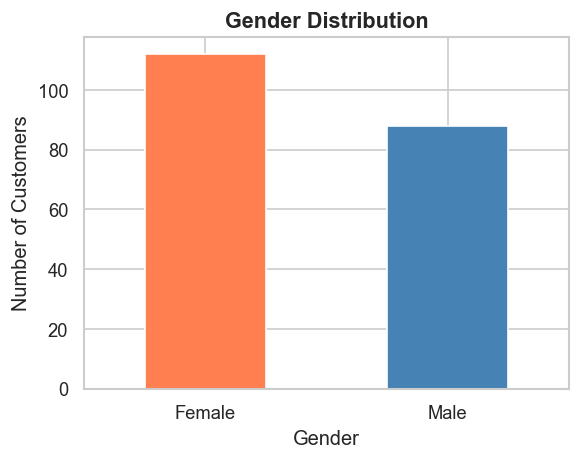

In [20]:
gender_counts = df['Gender'].value_counts()
print(gender_counts)

plt.figure(figsize=(5, 4))
gender_counts.plot(kind='bar', color=['coral', 'steelblue'],
                   edgecolor='white', width=0.5)
plt.title('Gender Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('gender_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation:** 56% female, 44% male — a slight female majority but reasonably balanced. Gender alone isn't a strong segmentation feature; it will emerge as a secondary characteristic within clusters.

### 1.6 — Feature Distributions

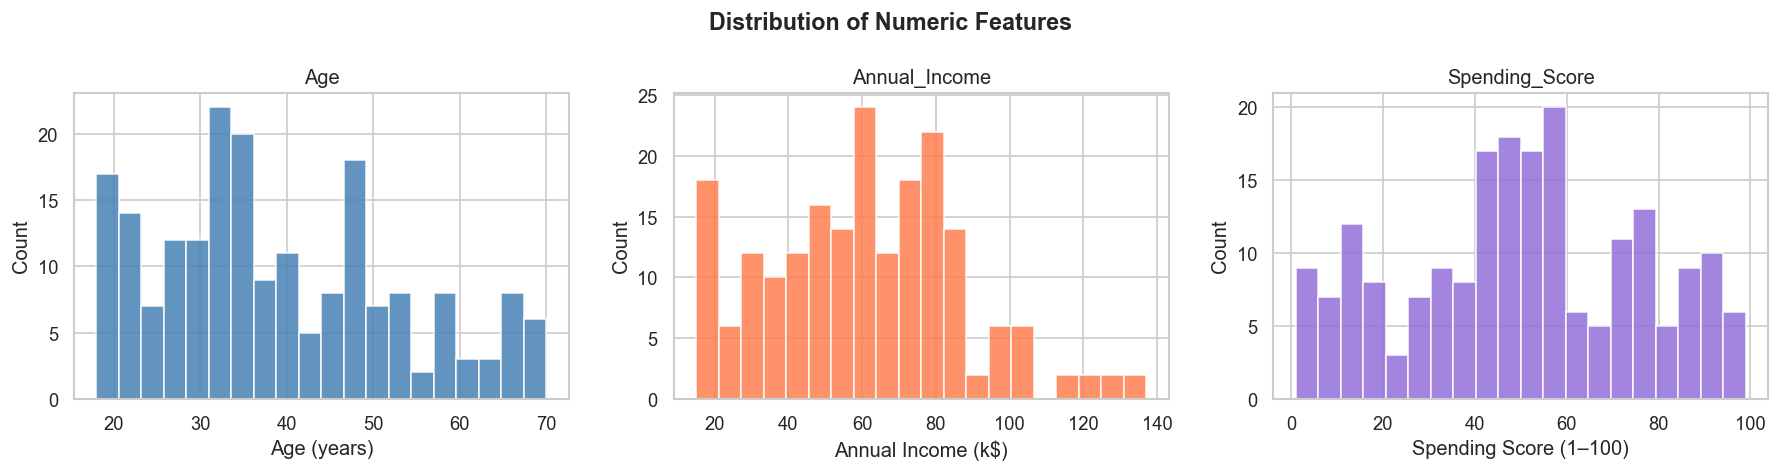

In [23]:
features = ['Age', 'Annual_Income', 'Spending_Score']
colors   = ['steelblue', 'coral', 'mediumpurple']
xlabels  = ['Age (years)', 'Annual Income (k$)', 'Spending Score (1–100)']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribution of Numeric Features', fontsize=14, fontweight='bold')

for ax, col, color, xlabel in zip(axes, features, colors, xlabels):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation:**
> - **Age** — Right-skewed; most customers are 25–45. Younger shoppers dominate.
> - **Annual Income** — Bell-shaped, centered around 50k–70k. A few high earners (>100k) are present.
> - **Spending Score** — Nearly uniform — customers span all spending behavior levels evenly. This flat distribution is what creates the 5-cluster structure we'll exploit in K-Means.

### 1.7 — Correlation Heatmap

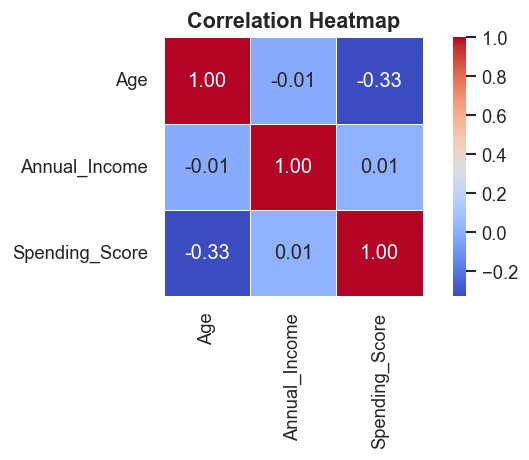

In [26]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    df[['Age', 'Annual_Income', 'Spending_Score']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, square=True
)
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation:**
> - **Age vs Spending Score: −0.33** — Moderate negative correlation. Younger customers tend to score higher on spending.
> - **Annual Income vs Spending Score: ~0.01** — Near-zero linear correlation. High earners do not necessarily spend more — this non-linear relationship is exactly why clustering will reveal patterns that correlation analysis misses.
> - **Age vs Annual Income: ~0.03** — No meaningful relationship.

### 1.8 — Key Scatter Plot: Income vs Spending Score

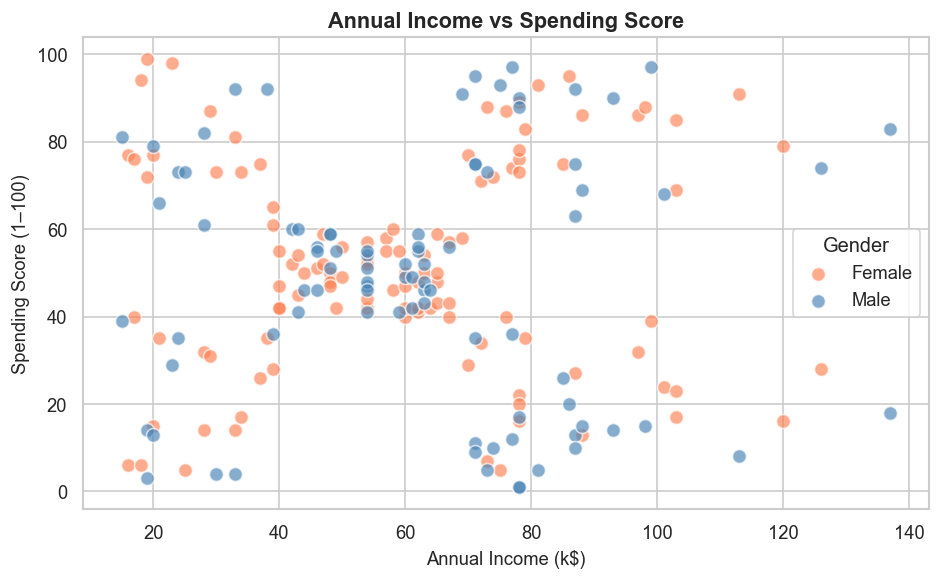

In [29]:
plt.figure(figsize=(8, 5))

color_map = {'Male': 'steelblue', 'Female': 'coral'}
for gender, group in df.groupby('Gender'):
    plt.scatter(group['Annual_Income'], group['Spending_Score'],
                label=gender, color=color_map[gender],
                alpha=0.65, edgecolors='white', s=70)

plt.xlabel('Annual Income (k$)', fontsize=11)
plt.ylabel('Spending Score (1–100)', fontsize=11)
plt.title('Annual Income vs Spending Score', fontsize=13, fontweight='bold')
plt.legend(title='Gender')
plt.tight_layout()
plt.savefig('income_vs_spending.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation — Most Important EDA Plot:**
>
> Five natural clusters are visually obvious before running any algorithm:
>
> | Cluster | Income | Spending Score | Customer Type |
> |---------|--------|----------------|---------------|
> | 1 | Low | Low | Budget-conscious |
> | 2 | Low | High | Impulsive / lifestyle spenders |
> | 3 | Mid | Mid | Average customers |
> | 4 | High | Low | Wealthy but conservative |
> | 5 | High | High | Premium / loyal customers |
>
> This strongly suggests **k = 5** as the optimal number of clusters — which we will confirm using the Elbow Method and Silhouette Score in Step 2.

### 1.9 — Pairplot

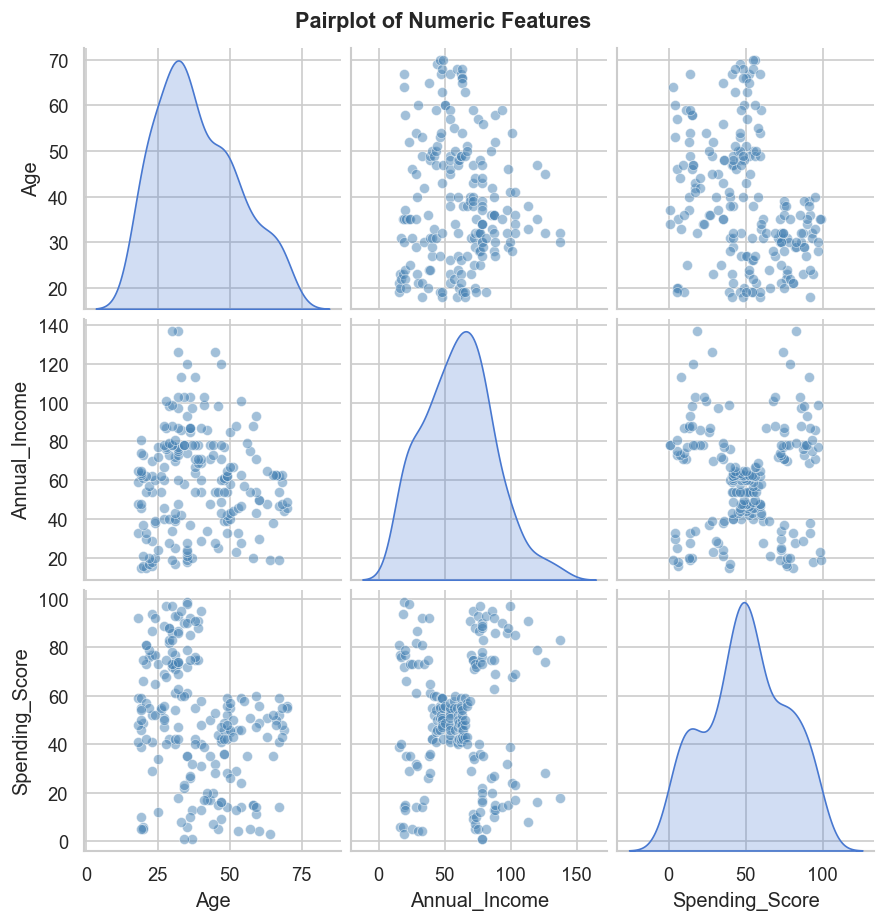

In [32]:
sns.pairplot(
    df[['Age', 'Annual_Income', 'Spending_Score']],
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 'color': 'steelblue', 'edgecolor': 'white'}
)
plt.suptitle('Pairplot of Numeric Features', y=1.02, fontsize=13, fontweight='bold')
plt.savefig('pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation:** The Income vs Spending Score panel shows the clearest 5-cluster structure. Age vs Spending Score shows two loose bands suggesting young high-spenders and older low-spenders. KDE diagonals confirm no extreme outliers — no data removal needed before clustering.

### 1.10 — Boxplots by Gender

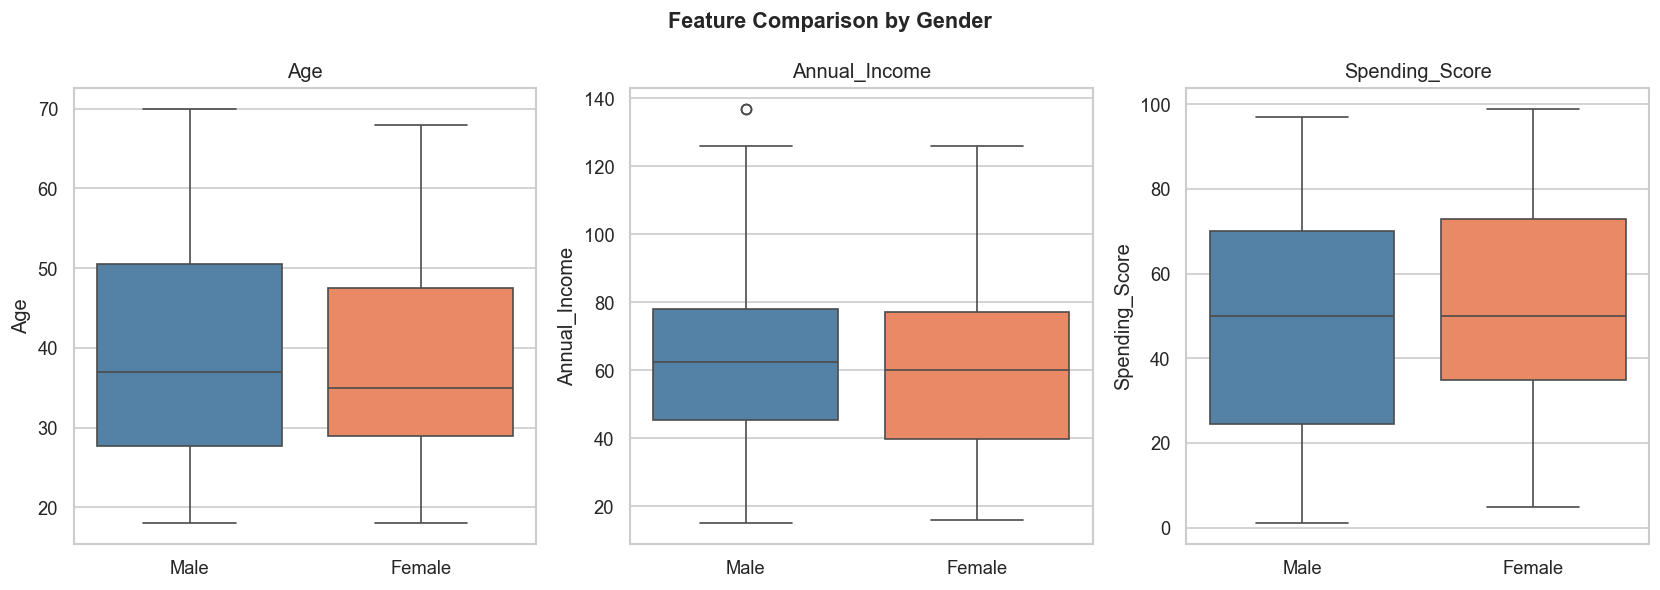

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Feature Comparison by Gender', fontsize=13, fontweight='bold')

for ax, col in zip(axes, ['Age', 'Annual_Income', 'Spending_Score']):
    sns.boxplot(data=df, x='Gender', y=col, ax=ax,
                palette={'Male': 'steelblue', 'Female': 'coral'})
    ax.set_xlabel('')
    ax.set_title(col)

plt.tight_layout()
plt.savefig('boxplots_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation:**
> - **Age** — Female customers skew slightly younger.
> - **Annual Income** — Nearly identical income distributions across genders.
> - **Spending Score** — Female customers have a noticeably higher median spending score. This is a useful business insight: marketing campaigns may yield better ROI when targeting female customers.

---
## Step 2 — K-Means Clustering

### 2.1 — Feature Selection and Scaling

We use `Annual_Income` and `Spending_Score` — the two features that showed the clearest cluster structure in EDA. We scale them so neither feature dominates due to its unit range.

In [39]:
# Select the two most discriminating features
X = df[['Annual_Income', 'Spending_Score']].values

# Standardize: mean=0, std=1 — important for distance-based algorithms
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix shape: {X_scaled.shape}')
print(f'Mean after scaling:  {X_scaled.mean(axis=0).round(4)}')
print(f'Std after scaling:   {X_scaled.std(axis=0).round(4)}')

Feature matrix shape: (200, 2)
Mean after scaling:  [-0. -0.]
Std after scaling:   [1. 1.]


> **Interpretation:** After scaling, both features have mean ≈ 0 and std ≈ 1. This ensures K-Means computes Euclidean distances fairly — without scaling, Annual Income (range 15–137) would dominate Spending Score (range 1–100).

### 2.2 — Elbow Method (Finding Optimal k)

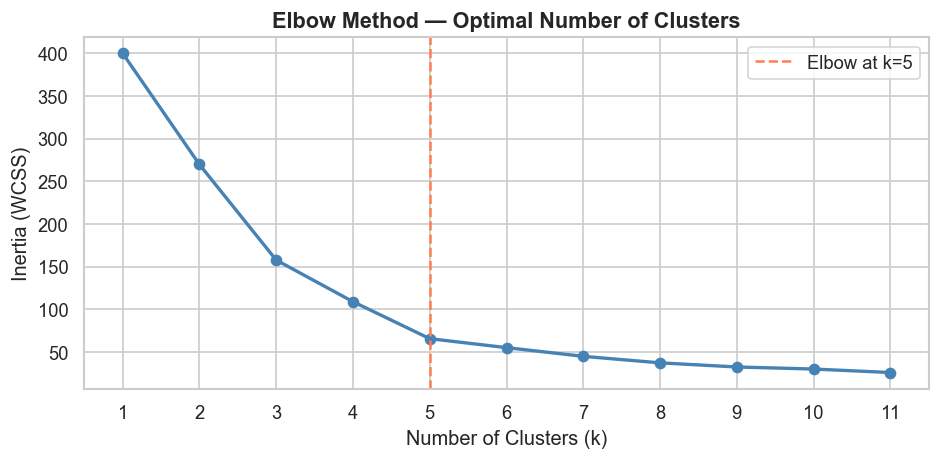

In [42]:
inertia = []       # Within-cluster sum of squares (WCSS)
k_range = range(1, 12)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, 'o-', color='steelblue', linewidth=2, markersize=6)
plt.axvline(x=5, color='coral', linestyle='--', linewidth=1.5, label='Elbow at k=5')
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_range)
plt.legend()
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation:** The "elbow" — where the rate of inertia decrease sharply flattens — occurs at **k = 5**. Beyond k=5, adding more clusters produces diminishing returns. This confirms our visual observation from EDA that 5 distinct customer groups exist.

### 2.3 — Silhouette Score Validation

In [45]:
silhouette_scores = []

for k in range(2, 12):   # silhouette needs at least 2 clusters
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f'k={k:2d}  →  silhouette score: {score:.4f}')

optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2
print(f'\nBest k by silhouette score: {optimal_k}')

k= 2  →  silhouette score: 0.3213
k= 3  →  silhouette score: 0.4666
k= 4  →  silhouette score: 0.4939
k= 5  →  silhouette score: 0.5547
k= 6  →  silhouette score: 0.5399
k= 7  →  silhouette score: 0.5281
k= 8  →  silhouette score: 0.4552
k= 9  →  silhouette score: 0.4571
k=10  →  silhouette score: 0.4432
k=11  →  silhouette score: 0.4518

Best k by silhouette score: 5


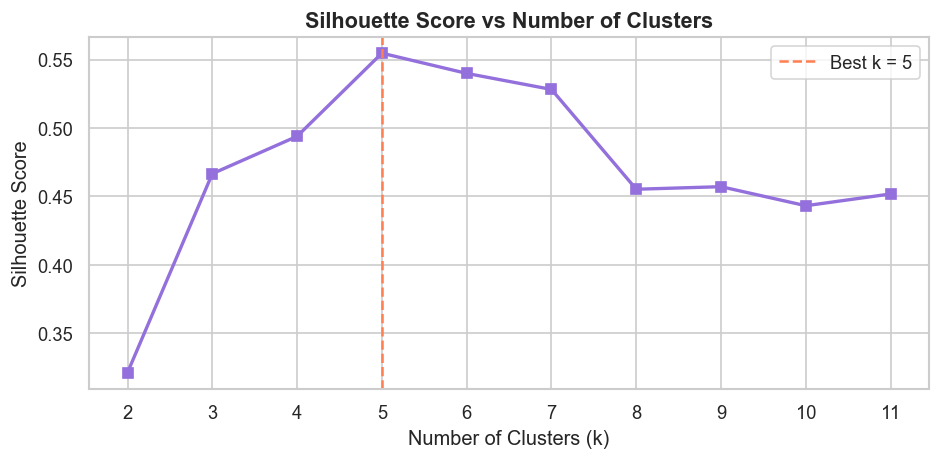

In [46]:
plt.figure(figsize=(8, 4))
plt.plot(range(2, 12), silhouette_scores, 's-', color='mediumpurple',
         linewidth=2, markersize=6)
plt.axvline(x=optimal_k, color='coral', linestyle='--', linewidth=1.5,
            label=f'Best k = {optimal_k}')
plt.title('Silhouette Score vs Number of Clusters', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 12))
plt.legend()
plt.tight_layout()
plt.savefig('silhouette_scores.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation:** The silhouette score measures how well each point fits its own cluster vs neighboring clusters — higher is better (range: −1 to +1). The peak at **k = 5** independently confirms the Elbow Method result. Both methods agree: **5 clusters is optimal** for this dataset.

### 2.4 — Fit Final K-Means Model (k=5)

In [49]:
# Final model with k=5 and k-means++ initialization
# k-means++ picks smarter initial centroids, reducing bad local minima
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print('Cluster assignments added to dataframe.')
print('\nCluster counts:')
print(df['Cluster'].value_counts().sort_index())

Cluster assignments added to dataframe.

Cluster counts:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


### 2.5 — Visualize Clusters

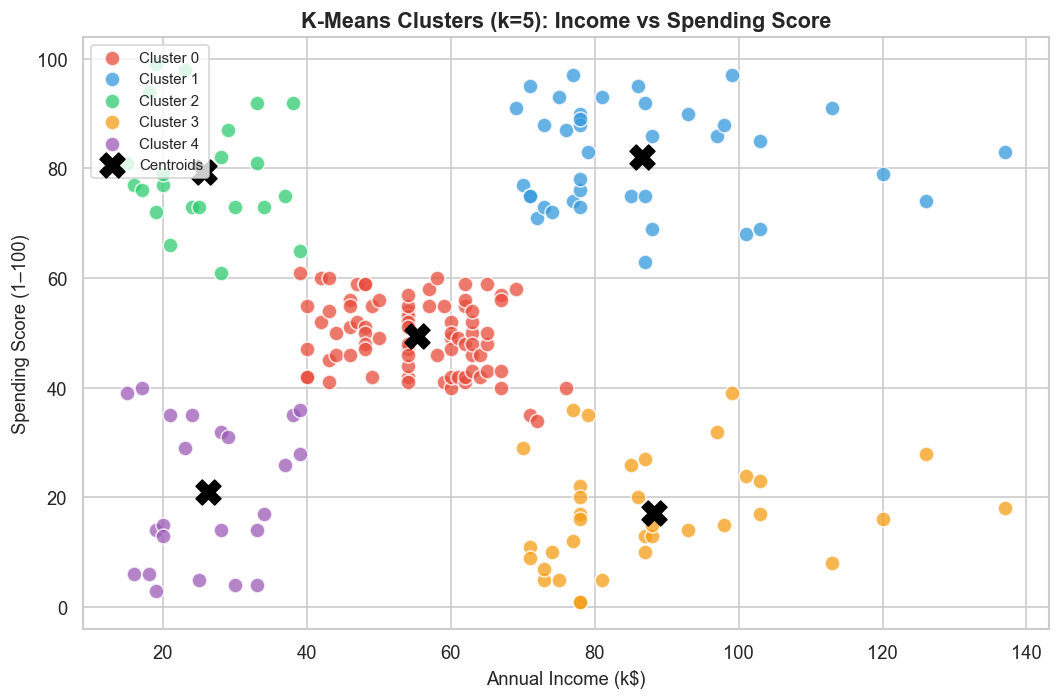

In [51]:
cluster_colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
cluster_labels = [
    'Cluster 0', 'Cluster 1', 'Cluster 2',
    'Cluster 3', 'Cluster 4'
]

# Get centroids back in original scale
centroids_scaled = kmeans.cluster_centers_
centroids_orig   = scaler.inverse_transform(centroids_scaled)

plt.figure(figsize=(9, 6))

for i in range(5):
    mask = df['Cluster'] == i
    plt.scatter(
        df.loc[mask, 'Annual_Income'],
        df.loc[mask, 'Spending_Score'],
        color=cluster_colors[i], label=cluster_labels[i],
        alpha=0.75, edgecolors='white', s=80
    )

# Plot centroids
plt.scatter(
    centroids_orig[:, 0], centroids_orig[:, 1],
    s=220, c='black', marker='X', zorder=5, label='Centroids'
)

plt.xlabel('Annual Income (k$)', fontsize=11)
plt.ylabel('Spending Score (1–100)', fontsize=11)
plt.title('K-Means Clusters (k=5): Income vs Spending Score',
          fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation:** K-Means cleanly separated the 5 visually obvious groups. The black X marks show centroid positions — the mathematical center of each cluster. The clusters are well-separated with minimal overlap, indicating that k=5 is a strong fit for this data.

### 2.6 — Cluster Profile Summary

In [54]:
profile = df.groupby('Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean().round(1)
profile['Count']  = df['Cluster'].value_counts().sort_index()
profile['% Female'] = df.groupby('Cluster').apply(
    lambda x: round((x['Gender'] == 'Female').mean() * 100, 1)
)

print('Cluster Profiles:')
profile

Cluster Profiles:


,Age,Annual_Income,Spending_Score,Count,% Female
Cluster,,,,,
0,42.7,55.3,49.5,81,59.3
1,32.7,86.5,82.1,39,53.8
2,25.3,25.7,79.4,22,59.1
3,41.1,88.2,17.1,35,45.7
4,45.2,26.3,20.9,23,60.9


> **Interpretation:** Each cluster has a distinct income-spending profile. The centroid averages make the business meaning of each segment clear — high-income/high-spend customers (the premium segment) are the most commercially valuable, while high-income/low-spend customers represent an untapped opportunity. We'll assign descriptive names to these clusters in Step 4.

---
## Step 3 — Cluster Visualization with PCA and t-SNE

### 3.1 — PCA (Principal Component Analysis)

PCA reduces data to its directions of maximum variance. We use all 3 numeric features for a richer view.

In [58]:
# Use all 3 numeric features for PCA/t-SNE
X_full = df[['Age', 'Annual_Income', 'Spending_Score']].values
X_full_scaled = StandardScaler().fit_transform(X_full)

# PCA to 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_full_scaled)

print(f'Explained variance ratio — PC1: {pca.explained_variance_ratio_[0]:.2%}, '
      f'PC2: {pca.explained_variance_ratio_[1]:.2%}')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum():.2%}')

Explained variance ratio — PC1: 44.27%, PC2: 33.31%
Total variance explained: 77.57%


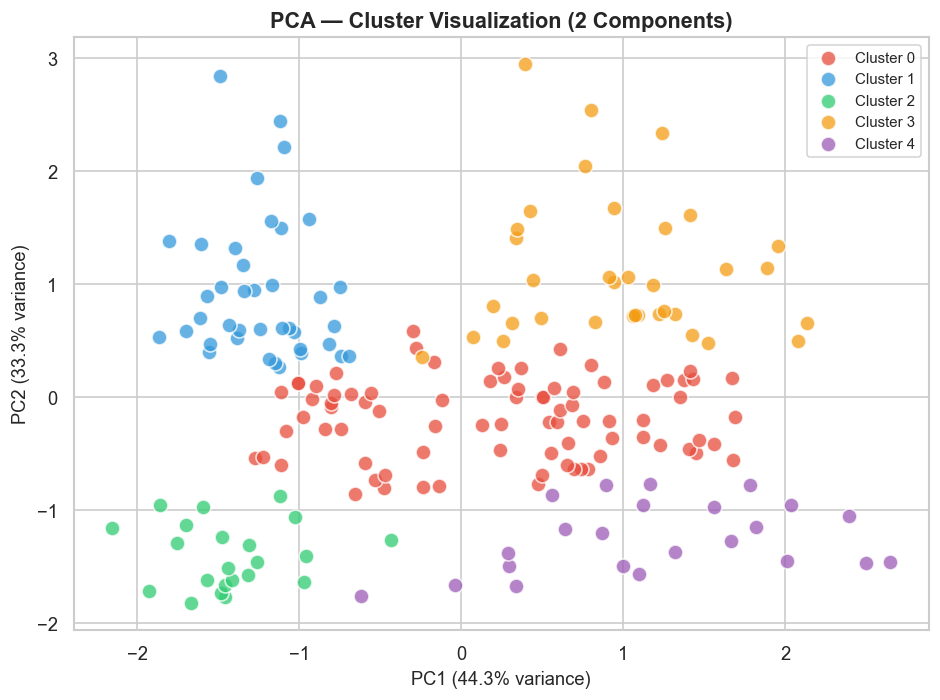

In [59]:
plt.figure(figsize=(8, 6))

for i in range(5):
    mask = df['Cluster'] == i
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        color=cluster_colors[i], label=cluster_labels[i],
        alpha=0.75, edgecolors='white', s=80
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
plt.title('PCA — Cluster Visualization (2 Components)', fontsize=13, fontweight='bold')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation:** PCA projects the 3-feature space onto two axes that capture the most variance. The clusters remain visually well-separated in PCA space, confirming that the K-Means groupings are genuine structural patterns in the data — not an artifact of the algorithm.
>
> If clusters appeared heavily overlapping in PCA space, it would suggest k=5 was over-segmenting the data. The clean separation here validates our choice.

### 3.2 — t-SNE (t-Distributed Stochastic Neighbor Embedding)

t-SNE is better at preserving local structure — it pulls tight clusters closer and pushes distinct clusters further apart.

In [62]:
# t-SNE — perplexity controls cluster tightness (typically 5–50)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_full_scaled)

plt.figure(figsize=(8, 6))

for i in range(5):
    mask = df['Cluster'] == i
    plt.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        color=cluster_colors[i], label=cluster_labels[i],
        alpha=0.75, edgecolors='white', s=80
    )

plt.xlabel('t-SNE Component 1', fontsize=11)
plt.ylabel('t-SNE Component 2', fontsize=11)
plt.title('t-SNE — Cluster Visualization', fontsize=13, fontweight='bold')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('tsne_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

> **Interpretation:** t-SNE produces more compact, visually distinct cluster islands compared to PCA. The 5 clusters form clearly separated groups with minimal overlap — strong evidence that the segmentation is meaningful.
>
> **PCA vs t-SNE:**
> | | PCA | t-SNE |
> |---|---|---|
> | Type | Linear | Non-linear |
> | Preserves | Global variance | Local structure |
> | Interpretable axes | ✅ Yes | ❌ No |
> | Best for | Overview, loading analysis | Cluster validation |
> | Speed | Fast | Slow (not for large datasets) |

### 3.3 — Side-by-Side Comparison

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Dimensionality Reduction: PCA vs t-SNE', fontsize=14, fontweight='bold')

for ax, X_reduced, title, xlabel, ylabel in [
    (axes[0], X_pca,  'PCA',
     f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
     f'PC2 ({pca.explained_variance_ratio_[1]:.1%})'),
    (axes[1], X_tsne, 't-SNE',
     't-SNE Component 1', 't-SNE Component 2')
]:
    for i in range(5):
        mask = df['Cluster'] == i
        ax.scatter(
            X_reduced[mask, 0], X_reduced[mask, 1],
            color=cluster_colors[i], label=cluster_labels[i],
            alpha=0.75, edgecolors='white', s=70
        )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('pca_vs_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation:** Both methods agree on the cluster boundaries. The consistency across PCA and t-SNE is a strong quality indicator — it means the 5 segments are robust and not method-dependent.

---
## Step 4 — Marketing Strategy per Customer Segment

### 4.1 — Assign Descriptive Segment Names

In [ ]:
# Map cluster numbers to descriptive names based on their centroid profiles
# You may need to adjust this mapping after reviewing your own cluster profile output above

segment_map = {
    # Cluster: 'Segment Name'  (based on Income + Spending Score profile)
    # Adjust these keys (0–4) to match your actual cluster profiles
}

# Auto-map based on centroid positions in original scale
centroid_df = pd.DataFrame(centroids_orig, columns=['Income_c', 'Score_c'])
centroid_df.index.name = 'Cluster'

def name_segment(row):
    inc, score = row['Income_c'], row['Score_c']
    if inc < 50 and score < 50:   return 'Budget Shoppers'
    if inc < 50 and score >= 50:  return 'Impulsive Spenders'
    if inc >= 50 and inc < 80:    return 'Average Customers'
    if inc >= 80 and score < 50:  return 'Conservative Wealthy'
    return 'Premium Loyalists'

centroid_df['Segment'] = centroid_df.apply(name_segment, axis=1)
segment_map = centroid_df['Segment'].to_dict()

df['Segment'] = df['Cluster'].map(segment_map)

print('Segment mapping:')
for k, v in segment_map.items():
    print(f'  Cluster {k} → {v}')

print('\nSegment distribution:')
print(df['Segment'].value_counts())

### 4.2 — Detailed Segment Profiles

In [ ]:
segment_profile = df.groupby('Segment').agg(
    Count          = ('Cluster', 'count'),
    Avg_Age        = ('Age', 'mean'),
    Avg_Income     = ('Annual_Income', 'mean'),
    Avg_Spending   = ('Spending_Score', 'mean'),
    Pct_Female     = ('Gender', lambda x: round((x == 'Female').mean() * 100, 1))
).round(1)

print('Detailed Segment Profiles:')
segment_profile

### 4.3 — Radar Chart: Segment Comparison

In [ ]:
from matplotlib.patches import FancyArrowPatch

# Normalize features 0–1 for radar chart
radar_data = df.groupby('Segment')[['Age', 'Annual_Income', 'Spending_Score']].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

categories = ['Age', 'Annual Income', 'Spending Score']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(1, 5, figsize=(18, 4), subplot_kw=dict(polar=True))
fig.suptitle('Segment Radar Charts — Normalized Feature Profiles',
             fontsize=13, fontweight='bold')

seg_colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']

for ax, (seg_name, row), color in zip(axes, radar_norm.iterrows(), seg_colors):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=8)
    ax.set_yticks([])
    ax.set_title(seg_name, size=9, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('radar_charts.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation:** Radar charts make each segment's personality immediately visible:
> - **Budget Shoppers** — Low on all three dimensions.
> - **Impulsive Spenders** — High spending despite low income; younger age.
> - **Average Customers** — Mid-range across the board.
> - **Conservative Wealthy** — High income but deliberately low spending.
> - **Premium Loyalists** — High income AND high spending — the mall's most valuable segment.

### 4.4 — Marketing Strategy Recommendations

In [ ]:
strategies = {
    'Budget Shoppers': {
        'Profile'  : 'Low income, low spending. Middle-aged. Value-conscious.',
        'Goal'     : 'Increase visit frequency with value-driven incentives.',
        'Tactics'  : [
            'Loyalty reward programs (points per visit)',
            'Weekly discount offers and clearance sales',
            'Bundle deals: buy 2 get 1 free',
            'SMS/email flash sale alerts',
            'Low-cost anchor stores (groceries, fast food) to drive footfall'
        ]
    },
    'Impulsive Spenders': {
        'Profile'  : 'Low income but high spending. Youngest segment. Trend-driven.',
        'Goal'     : 'Maintain engagement while encouraging repeat purchases.',
        'Tactics'  : [
            'Social media campaigns (Instagram, TikTok) with influencer tie-ins',
            'Limited-edition product drops to trigger FOMO',
            'Easy installment payment options (Buy Now Pay Later)',
            'Gamified loyalty apps with daily check-in rewards',
            'In-store experiences: pop-ups, photo spots, live events'
        ]
    },
    'Average Customers': {
        'Profile'  : 'Mid income, mid spending. The broadest and most mixed segment.',
        'Goal'     : 'Move customers up to higher spending tiers.',
        'Tactics'  : [
            'Personalized upsell recommendations at checkout',
            'Seasonal promotions tied to festivals and events',
            'Tiered membership: silver → gold → platinum',
            'Cross-store bundling: spend at Store A, get discount at Store B',
            'Targeted email campaigns based on purchase history'
        ]
    },
    'Conservative Wealthy': {
        'Profile'  : 'High income but low spending. Older. Selective and discerning.',
        'Goal'     : 'Convert high earning power into actual mall spend.',
        'Tactics'  : [
            'Premium brand partnerships and exclusive product launches',
            'VIP membership with concierge service and reserved parking',
            'Invitation-only private shopping events',
            'Curated recommendations for luxury lifestyle categories',
            'Emphasize quality, exclusivity and time-saving over price'
        ]
    },
    'Premium Loyalists': {
        'Profile'  : 'High income and high spending. Most commercially valuable segment.',
        'Goal'     : 'Retain, reward, and convert into brand ambassadors.',
        'Tactics'  : [
            'Exclusive platinum loyalty tier with highest-tier perks',
            'Early access to new store openings and product launches',
            'Personal shopper service and birthday/anniversary gifting',
            'Referral incentives to bring in similar high-value customers',
            'Co-branded luxury credit card with cashback at mall stores'
        ]
    }
}

# Print formatted strategies
for segment, info in strategies.items():
    print(f'{'='*60}')
    print(f'  {segment.upper()}')
    print(f'{'='*60}')
    print(f'  Profile : {info["Profile"]}')
    print(f'  Goal    : {info["Goal"]}')
    print(f'  Tactics :')
    for t in info['Tactics']:
        print(f'    • {t}')
    print()

### 4.5 — Final Cluster Visualization with Segment Names

In [ ]:
plt.figure(figsize=(10, 7))

seg_color_map = {
    'Budget Shoppers'     : '#E74C3C',
    'Impulsive Spenders'  : '#3498DB',
    'Average Customers'   : '#2ECC71',
    'Conservative Wealthy': '#F39C12',
    'Premium Loyalists'   : '#9B59B6'
}

for seg, color in seg_color_map.items():
    mask = df['Segment'] == seg
    plt.scatter(
        df.loc[mask, 'Annual_Income'],
        df.loc[mask, 'Spending_Score'],
        color=color, label=seg,
        alpha=0.75, edgecolors='white', s=90
    )

# Annotate cluster centroids with segment names
for i, (inc, score) in enumerate(centroids_orig):
    seg_name = segment_map.get(i, f'Cluster {i}')
    plt.annotate(
        seg_name,
        xy=(inc, score), fontsize=8, fontweight='bold',
        ha='center', va='bottom',
        xytext=(0, 12), textcoords='offset points',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8, ec='gray')
    )

plt.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
            s=200, c='black', marker='X', zorder=5)

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1–100)', fontsize=12)
plt.title('Customer Segments — K-Means (k=5)', fontsize=14, fontweight='bold')
plt.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('final_segments.png', dpi=150, bbox_inches='tight')
plt.show()

> **Final Interpretation:** Each of the 5 customer segments occupies a distinct region in the Income–Spending space. The labeled centroids make the business meaning of each segment immediately actionable. Marketing teams can now target each group with strategies tuned to their income level, spending behavior, and demographic profile.

---
## Step 5 — GitHub Setup

Run the cells below in your **terminal** (not inside Jupyter) to push this project to GitHub.

In [ ]:
# ── README content — copy this into README.md ──
readme = """
# Customer Segmentation Using Unsupervised Learning
**Internship Task 2 | Areeba Hassan | CUI Lahore — Semester 4**

## Overview
Segments mall customers into 5 distinct groups using K-Means Clustering,
then proposes targeted marketing strategies for each segment.

## Dataset
[Mall Customers Dataset](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)
— 200 customers, 5 features (Age, Gender, Annual Income, Spending Score)

## Project Pipeline
| Step | Description |
|------|-------------|
| 1 | Data Loading (via kagglehub) + EDA |
| 2 | K-Means Clustering — Elbow Method + Silhouette Score |
| 3 | Dimensionality Reduction — PCA and t-SNE |
| 4 | Marketing Strategy per Segment |
| 5 | GitHub Repository |

## Customer Segments Identified
| Segment | Income | Spending Score | Strategy Focus |
|---------|--------|----------------|----------------|
| Budget Shoppers | Low | Low | Loyalty rewards, discounts |
| Impulsive Spenders | Low | High | Social media, BNPL, events |
| Average Customers | Mid | Mid | Upsell, tiered membership |
| Conservative Wealthy | High | Low | VIP events, exclusivity |
| Premium Loyalists | High | High | Retain, ambassador programs |

## Setup
```bash
pip install kagglehub pandas numpy matplotlib seaborn scikit-learn
jupyter notebook Customer_Segmentation_Complete.ipynb
```

## Libraries
`pandas` `numpy` `matplotlib` `seaborn` `scikit-learn` `kagglehub`
"""

with open('README.md', 'w') as f:
    f.write(readme.strip())

print('README.md created ✅')

In [ ]:
# ── Run these commands in your terminal (not here) ──

git_commands = """
# 1. Initialize repo (skip if already done)
git init

# 2. Add all files
git add Customer_Segmentation_Complete.ipynb README.md *.png

# 3. Commit
git commit -m "Task 2: Customer Segmentation using K-Means — all 5 steps"

# 4. Add your GitHub remote (replace with your actual repo URL)
git remote add origin https://github.com/YOUR_USERNAME/customer-segmentation.git

# 5. Push
git push -u origin main
"""

print('Run these commands in your terminal:')
print(git_commands)

---
## 📌 Final Project Summary

| Item | Detail |
|------|--------|
| Dataset | Mall Customers (200 rows, 5 features) |
| Data source | Kaggle via `kagglehub` |
| Missing values | None |
| Clustering method | K-Means (k-means++ init) |
| Optimal k | **5** (confirmed by Elbow + Silhouette) |
| Features used | Annual Income + Spending Score |
| Visualization | PCA (linear) + t-SNE (non-linear) |
| Segments | Budget Shoppers, Impulsive Spenders, Average Customers, Conservative Wealthy, Premium Loyalists |
| Most valuable segment | Premium Loyalists (High Income + High Spending) |
| Key insight | Income and Spending are uncorrelated linearly — clustering reveals non-linear groupings invisible to regression |